In [16]:
# %% [markdown]
# # DC Optimal Power Flow with Topology Switching
# 

# **Author:** Erik G.
# **System:** IEEE 14/57-bus test case
# ** Adapted off Pooja's IEEE 14 that Pascal validated for 57-bus to between bus angle bound and aligned to model 4 and MathFormulation_DC_OPT_BigM_binary.ipynb

# %% [markdown]
# ## 1. Setup and Imports

# %%
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import gurobipy as gp
from gurobipy import GRB
from IPython.display import display, Markdown

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

print("Libraries loaded successfully!")



Libraries loaded successfully!


In [17]:
def extract_matrix_block(lines, varname):
    in_block = False
    matrix_lines = []

    for line in lines:
        if line.strip().startswith(f"{varname} = ["):
            in_block = True
            continue
        if in_block:
            if line.strip().startswith("];"):
                break
            clean = re.sub(r'%.*', '', line).strip().rstrip(';')
            if clean:
                matrix_lines.append(clean)

    matrix_data = []
    for line in matrix_lines:
        row = [float(x) for x in line.split()]
        matrix_data.append(row)
    
    return np.array(matrix_data)

def extract_scalar(lines, varname):
    """Extract a scalar value like mpc.baseMVA = 100.0"""
    for line in lines:
        if varname in line and '=' in line:
            # Extract the number after '='
            parts = line.split('=')
            if len(parts) == 2:
                value_str = parts[1].strip().rstrip(';')
                try:
                    return float(value_str)
                except:
                    pass
    return None

# Load m file path
path = '/Users/egoh02/Github/pglib-opf/pglib_opf_case57_ieee.m'

with open(path, 'r') as f:
    lines = f.readlines()

# baseMVA function, warn if data set has a different baseMVA, warn.
baseMVA = extract_scalar(lines, 'mpc.baseMVA')
if baseMVA == 100.0:
    pass
else:
    print(f"Extracted baseMVA = {baseMVA}. If baseMVA is not 100, adjust accordingly in the model.")

bus = extract_matrix_block(lines, 'mpc.bus')
branch = extract_matrix_block(lines, 'mpc.branch')
gen = extract_matrix_block(lines, 'mpc.gen')
gencost = extract_matrix_block(lines, 'mpc.gencost')

# Added descriptive column names:

bus_df= pd.DataFrame(bus, columns=[
'bus_i [bus index]',
'type [bus type: PQ/PV/ref/isolated]',
'Pd [active demand MW]',
'Qd [reactive demand MVAr]',
'Gs [shunt conductance MW@1pu]',
'Bs [shunt susceptance MVAr@1pu]',
'area [area id]',
'Vm [voltage mag pu]',
'Va [voltage angle deg]',
'baseKV [nominal kV]',
'zone [loss/zone id]',
'Vmax [volt upper pu]',
'Vmin [volt lower pu]' 
])

gen_df = pd.DataFrame(gen, columns=[
'bus [connection bus]',
'Pg [active output MW]',
'Qg [reactive output MVAr]',
'Qmax [reactive max MVAr]',
'Qmin [reactive min MVAr]',
'Vg [gen voltage setpoint pu]',
'mBase [machine base MVA]',
'status [in-service 0/1]',
'Pmax [active max MW]',
'Pmin [active min MW]' 
])

branch_df = pd.DataFrame(branch, columns=[
'fbus [from-bus]',
'tbus [to-bus]',
'r [series resistance pu]',
'x [series reactance pu]',
'b [line charging pu]',
'rateA [thermal rating A]',
'rateB [thermal rating B]',
'rateC [thermal rating C]',
'ratio [tap ratio]',
'angle [phase shift deg]',
'status [in-service 0/1]',
'angmin [angle min deg]',
'angmax [angle max deg]' 
])

gencost_df = pd.DataFrame(gencost, columns=[
'model [cost model code]',
'startup [startup cost]',
'shutdown [shutdown cost]',
'n [num coeffs/points]',
'c2 [quadratic coef]',
'c1 [linear coef]',
'c0 [constant term]' 
])


In [18]:
# %% [markdown]
# ## 3. Load IEEE 57-Bus System


print("="*60)
print("IEEE 57-BUS SYSTEM LOADED")
print("="*60)
print(f"Number of Buses: {len(bus_df)}")
print(f"Number of Generators: {len(gen_df)}")
print(f"Number of Branches: {len(branch_df)}")
print(f"Total Load: {bus_df['Pd [active demand MW]'].sum():.2f} MW")
print(f"Total Generation Capacity: {gen_df['Pmax [active max MW]'].sum():.2f} MW")

# %% [markdown]
# ### 3.1 System Overview

for name, df in [
    ("bus_df", bus_df),
    ("gen_df", gen_df),
    ("branch_df", branch_df),
    ("gencost_df", gencost_df),
]:
    display(Markdown(f"### {name}  — shape={df.shape}"))
    # show full numeric precision trimmed to 4 decimals and keep all columns visible in Jupyter
    display(df.round(4))

IEEE 57-BUS SYSTEM LOADED
Number of Buses: 57
Number of Generators: 7
Number of Branches: 80
Total Load: 1250.80 MW
Total Generation Capacity: 1983.00 MW


### bus_df  — shape=(57, 13)

,bus_i [bus index],type [bus type: PQ/PV/ref/isolated],Pd [active demand MW],Qd [reactive demand MVAr],Gs [shunt conductance MW@1pu],Bs [shunt susceptance MVAr@1pu],area [area id],Vm [voltage mag pu],Va [voltage angle deg],baseKV [nominal kV],zone [loss/zone id],Vmax [volt upper pu],Vmin [volt lower pu]
0,1.0,3.0,55.0,17.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
1,2.0,2.0,3.0,88.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
2,3.0,2.0,41.0,21.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
3,4.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
4,5.0,1.0,13.0,4.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
5,6.0,2.0,75.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
6,7.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
7,8.0,2.0,150.0,22.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
8,9.0,2.0,121.0,26.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94
9,10.0,1.0,5.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.06,0.94


### gen_df  — shape=(7, 10)

,bus [connection bus],Pg [active output MW],Qg [reactive output MVAr],Qmax [reactive max MVAr],Qmin [reactive min MVAr],Vg [gen voltage setpoint pu],mBase [machine base MVA],status [in-service 0/1],Pmax [active max MW],Pmin [active min MW]
0,1.0,122.5,0.0,123.0,-123.0,1.0,100.0,1.0,245.0,0.0
1,2.0,0.0,16.5,50.0,-17.0,1.0,100.0,1.0,0.0,0.0
2,3.0,30.0,10.0,30.0,-10.0,1.0,100.0,1.0,60.0,0.0
3,6.0,0.0,8.5,25.0,-8.0,1.0,100.0,1.0,0.0,0.0
4,8.0,579.5,30.0,200.0,-140.0,1.0,100.0,1.0,1159.0,0.0
5,9.0,0.0,3.0,9.0,-3.0,1.0,100.0,1.0,0.0,0.0
6,12.0,259.5,2.5,155.0,-150.0,1.0,100.0,1.0,519.0,0.0


### branch_df  — shape=(80, 13)

,fbus [from-bus],tbus [to-bus],r [series resistance pu],x [series reactance pu],b [line charging pu],rateA [thermal rating A],rateB [thermal rating B],rateC [thermal rating C],ratio [tap ratio],angle [phase shift deg],status [in-service 0/1],angmin [angle min deg],angmax [angle max deg]
0,1.0,2.0,0.0083,0.0280,0.1290,1005.0,1005.0,1005.0,0.000,0.0,1.0,-30.0,30.0
1,2.0,3.0,0.0298,0.0850,0.0818,326.0,326.0,326.0,0.000,0.0,1.0,-30.0,30.0
2,3.0,4.0,0.0112,0.0366,0.0380,767.0,767.0,767.0,0.000,0.0,1.0,-30.0,30.0
3,4.0,5.0,0.0625,0.1320,0.0258,201.0,201.0,201.0,0.000,0.0,1.0,-30.0,30.0
4,4.0,6.0,0.0430,0.1480,0.0348,191.0,191.0,191.0,0.000,0.0,1.0,-30.0,30.0
5,6.0,7.0,0.0200,0.1020,0.0276,283.0,283.0,283.0,0.000,0.0,1.0,-30.0,30.0
6,6.0,8.0,0.0339,0.1730,0.0470,167.0,167.0,167.0,0.000,0.0,1.0,-30.0,30.0
7,8.0,9.0,0.0099,0.0505,0.0548,570.0,570.0,570.0,0.000,0.0,1.0,-30.0,30.0
8,9.0,10.0,0.0369,0.1679,0.0440,171.0,171.0,171.0,0.000,0.0,1.0,-30.0,30.0
9,9.0,11.0,0.0258,0.0848,0.0218,331.0,331.0,331.0,0.000,0.0,1.0,-30.0,30.0


### gencost_df  — shape=(7, 7)

,model [cost model code],startup [startup cost],shutdown [shutdown cost],n [num coeffs/points],c2 [quadratic coef],c1 [linear coef],c0 [constant term]
0,2.0,0.0,0.0,3.0,0.0,16.9606,0.0
1,2.0,0.0,0.0,3.0,0.0,0.0000,0.0
2,2.0,0.0,0.0,3.0,0.0,34.0756,0.0
3,2.0,0.0,0.0,3.0,0.0,0.0000,0.0
4,2.0,0.0,0.0,3.0,0.0,30.4410,0.0
5,2.0,0.0,0.0,3.0,0.0,0.0000,0.0
6,2.0,0.0,0.0,3.0,0.0,37.1890,0.0


In [19]:
# %% [markdown]
# ## 4. DC-OPF Solver

def solve_dc_opf(bus_df, gen_df, branch_df, gencost_df, switching=False, verbose=True):
    """
    Enhanced DC Optimal Power Flow Model with proper baseMVA scaling
    
    This adapted function uses the mathematically the DC-OPF formulation within the miro board/modle 4 of pglearn paper:
    - baseMVA multiplication for per-unit to MW conversion
    - Unbounded voltage angles (only angle differences between bus constrained)
    - Proper Big-M formulation for line switching
    
    """
    
    if verbose:
        print("="*70)
        print(f"Enhanced DC-OPF Model Setup")
        print(f"  Switching: {'ENABLED' if switching else 'DISABLED (Baseline)'}")
        print("="*70)
    
    model = gp.Model("DC-OPF-Enhanced-Switching" if switching else "DC-OPF-Enhanced-Baseline")
    
    if not verbose:
        model.setParam('OutputFlag', 0)


    # ========== Sets ==========
    buses = bus_df['bus_i [bus index]'].values
    branches = branch_df.index
    generators = gen_df.index
    baseMVA = 100.0  # Standard MATPOWER base

    # ========== Parameters ==========
    Pd = dict(zip(bus_df['bus_i [bus index]'], bus_df['Pd [active demand MW]']))
    gen_at_bus = {
        bus: gen_df[gen_df['bus [connection bus]'] == bus].index.tolist()
        for bus in bus_df['bus_i [bus index]']
    }
    
    # Big-M for switching constraints
    if switching:
        M_angle = np.radians(360)  # Conservative angle bound
        M_flow = branch_df['rateA [thermal rating A]'].max() * 2  # Conservative flow bound
        
        if verbose:
            print(f"\nBig-M Parameters:")
            print(f"  M_angle = {M_angle:.2f} rad ({np.degrees(M_angle):.1f}°)")
            print(f"  M_flow = {M_flow:.2f} MW")

    # ========== Decision Variables ==========
    Pg = model.addVars(generators, lb=0, name="Pg")
    theta = model.addVars(buses, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="theta")
    P_branch = model.addVars(branches, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="P_branch")
    
    if switching:
        z = model.addVars(branches, vtype=GRB.BINARY, name="z")
        # Warm start: all lines ON
        for idx in branches:
            z[idx].start = 1
    
    if verbose:
        print(f"\nDecision Variables:")
        print(f"  Pg: {len(generators)} generators")
        print(f"  theta: {len(buses)} buses")
        print(f"  P_branch: {len(branches)} branches")
        if switching:
            print(f"  z: {len(branches)} binary switching variables")

    # ========== 13a. Objective Function ==========
    # Minimize total generation cost: ∑_{i ∈ N} ∑_{j ∈ G_i} c_j * p_j^g
    obj = gp.QuadExpr()
    for i in generators:
        c1 = gencost_df.loc[i, 'c1 [linear coef]']
        obj += c1 * Pg[i]
    
    # Optional: small penalty for switching lines off
    if switching:
        for idx in branches:
            obj += 1.0 * (1 - z[idx])
    
    model.setObjective(obj, GRB.MINIMIZE)

    # ========== Constraints ==========
    
    # 13b. Power Balance at each bus (Nodal Power Conservation)
    # ∑_{j ∈ G_i} p_j^g - ∑_{e ∈ E_i} p_e^f + ∑_{e ∈ E_i^R} p_e^f = ∑_{j ∈ L_i} p_j^d + g_i^s  ∀i ∈ N
    Gs = dict(zip(bus_df['bus_i [bus index]'], bus_df['Gs [shunt conductance MW@1pu]']))
    
    for bus in buses:
        gen_sum = gp.quicksum(Pg[g] for g in gen_at_bus[bus]) if gen_at_bus[bus] else 0
        load = Pd[bus]
        
        # Branch flows: outflow from this bus
        outflow = gp.quicksum(P_branch[l] for l in branch_df[branch_df['fbus [from-bus]'] == bus].index)
        # Branch flows: inflow to this bus
        inflow = gp.quicksum(P_branch[l] for l in branch_df[branch_df['tbus [to-bus]'] == bus].index)
        
        model.addConstr(gen_sum - outflow + inflow == load + Gs[bus], name=f"power_balance_{int(bus)}")

    # Branch constraints
    for idx, row in branch_df.iterrows():
        i = row['fbus [from-bus]']
        j = row['tbus [to-bus]']
        x = row['x [series reactance pu]']
        rateA = row['rateA [thermal rating A]']
        angmin_rad = np.radians(row['angmin [angle min deg]'])
        angmax_rad = np.radians(row['angmax [angle max deg]'])
        
        if x == 0:
            model.addConstr(theta[i] == theta[j], name=f"dc_flow_{idx}_zero_x")
            continue
        
        if switching:
            # ===== SWITCHING MODE: Big-M Formulation =====
            
            # 13c.ii. DC Power Flow with Big-M (active power flow on each branch)
            # -M(1-z_e) ≤ -b_e(θ_i - θ_j)*baseMVA - p_e^f ≤ M(1-z_e)  ∀e = (i,j) ∈ E
            # When z_e = 1 (line closed): -b_e(θ_i - θ_j)*baseMVA - p_e^f = 0
            # When z_e = 0 (line open): constraint is relaxed by M
            model.addConstr(
                -(1/x) * (theta[i] - theta[j]) * baseMVA - P_branch[idx] <= M_flow * (1 - z[idx]),
                name=f"dc_flow_upper_{idx}"
            )
            model.addConstr(
                -(1/x) * (theta[i] - theta[j]) * baseMVA - P_branch[idx] >= -M_flow * (1 - z[idx]),
                name=f"dc_flow_lower_{idx}"
            )
            
            # 13d. Voltage Angle Difference Limits with Big-M
            # ∆θ_e^min - M(1-z_e) ≤ θ_i - θ_j ≤ ∆θ_e^max + M(1-z_e)  ∀e = (i,j) ∈ E
            # When z_e = 1 (line closed): angle differences are constrained
            # When z_e = 0 (line open): angle differences are decoupled
            if angmin_rad > -GRB.INFINITY:
                model.addConstr(
                    theta[i] - theta[j] >= angmin_rad - M_angle * (1 - z[idx]),
                    name=f"angle_min_{idx}",
                )
            if angmax_rad < GRB.INFINITY:
                model.addConstr(
                    theta[i] - theta[j] <= angmax_rad + M_angle * (1 - z[idx]),
                    name=f"angle_max_{idx}",
                )

            # 13g. Flow Limits (upper thermal limits) with switching
            # -\bar{S_e} · z_e ≤ p_e^f ≤ \bar{S_e} · z_e  ∀e ∈ E
            # When z_e = 0 (line open): flow p_e^f = 0
            # When z_e = 1 (line closed): flow is bounded by thermal limits
            if rateA > 0:
                model.addConstr(P_branch[idx] <= rateA * z[idx], name=f"line_max_{idx}")
                model.addConstr(P_branch[idx] >= -rateA * z[idx], name=f"line_min_{idx}")
        
        else:
            # ===== BASELINE MODE: All lines fixed ON (z_e = 1) =====
            
            # 13c.i. DC Power Flow (standard, no Big-M)
            # -b_e(θ_i - θ_j)*baseMVA - p_e^f = 0  ∀e = (i,j) ∈ E
            model.addConstr(
                -(1/x) * (theta[i] - theta[j]) * baseMVA - P_branch[idx] == 0,
                name=f"dc_flow_{idx}",
            )
            
            # 13d. Voltage Angle Difference Limits (standard)
            # ∆θ_e^min ≤ θ_i - θ_j ≤ ∆θ_e^max  ∀e = (i,j) ∈ E
            if angmin_rad > -GRB.INFINITY:
                model.addConstr(theta[i] - theta[j] >= angmin_rad, name=f"angmin [angle min deg]{idx}")
            if angmax_rad < GRB.INFINITY:
                model.addConstr(theta[i] - theta[j] <= angmax_rad, name=f"angmax [angle max deg]{idx}")

            # 13g. Line flow thermal limits (standard)
            # -\bar{S_e} ≤ p_e^f ≤ \bar{S_e}  ∀e ∈ E
            if rateA > 0:
                model.addConstr(P_branch[idx] <= rateA, name=f"line_max_{idx}")
                model.addConstr(P_branch[idx] >= -rateA, name=f"line_min_{idx}")

    # 13e. Reference Bus (fixes its voltage angle to zero)
    # θ_ref = 0
    ref_bus = bus_df[bus_df['type [bus type: PQ/PV/ref/isolated]'] == 3]['bus_i [bus index]'].values[0]
    model.addConstr(theta[ref_bus] == 0, name="reference_bus")

    # 13f. Generation Limits (active power generation limit at bus_i)
    # p_i^g^min ≤ p_i^g ≤ p_i^g^max  ∀i ∈ G
    for idx, row in gen_df.iterrows():
        model.addConstr(Pg[idx] >= row['Pmin [active min MW]'], name=f"Pg_min_{idx}")
        model.addConstr(Pg[idx] <= row['Pmax [active max MW]'], name=f"Pg_max_{idx}")

    # ========== Optimize ==========
    if verbose:
        print(f"\nOptimizing model...")
        print("-"*70)
    
    model.optimize()
    
    # ========== Extract Results ==========
    if verbose:
        print("-"*70)
        print(f"Optimization Status: {model.Status}")
    
    if model.Status == GRB.OPTIMAL:
        results = {
            'status': 'optimal',
            'obj_value': model.ObjVal,
            'Pg': {k: Pg[k].X for k in Pg.keys()},
            'theta': {k: theta[k].X for k in theta.keys()},
            'P_branch': {k: P_branch[k].X for k in P_branch.keys()},
        }
        
        if switching:
            results['z'] = {k: z[k].X for k in z.keys()}
        
        if verbose:
            print(f"✓ Optimal solution found")
            print(f"\nObjective Value (Total Cost): ${model.ObjVal:,.2f}")
            
            total_generation = sum(Pg[g].X for g in generators)
            total_demand = sum(Pd[bus] for bus in buses)
            print(f"\nPower Balance:")
            print(f"  Total Generation: {total_generation:.2f} MW")
            print(f"  Total Demand: {total_demand:.2f} MW")
            print(f"  Balance: {total_generation - total_demand:.6f} MW")
            
            # Calculate angle differences
            angle_diffs = []
            for idx, row in branch_df.iterrows():
                diff_rad = results['theta'][row['fbus [from-bus]']] - results['theta'][row['tbus [to-bus]']]
                diff_deg = diff_rad * 180 / np.pi
                angle_diffs.append(abs(diff_deg))
            
            print(f"\nAngle difference range: {min(angle_diffs):.1f}° to {max(angle_diffs):.1f}°")
            
            if switching:
                lines_open = sum(1 for idx in branches if z[idx].X < 0.5)
                lines_closed = sum(1 for idx in branches if z[idx].X > 0.5)
                print(f"\nLine Status:")
                print(f"  Lines Closed: {lines_closed}/{len(branches)}")
                print(f"  Lines Open: {lines_open}/{len(branches)}")
                
                if lines_open > 0:
                    print(f"\n  Open Lines:")
                    for idx in branches:
                        if z[idx].X < 0.5:
                            row = branch_df.loc[idx]
                            print(f"    Line {idx}: Bus {int(row['fbus [from-bus]'])} → Bus {int(row['tbus [to-bus]'])}")
        
        print("="*70)
        return model, results
    
    elif model.Status == GRB.INFEASIBLE:
        if verbose:
            print("✗ Model is infeasible")
            print("  Computing IIS (Irreducible Inconsistent Subsystem)...")
        model.computeIIS()
        model.write("model_iis.ilp")
        if verbose:
            print("  IIS written to 'model_iis.ilp'")
        return model, {'status': 'infeasible'}
    
    else:
        if verbose:
            print(f"✗ Model terminated with status: {model.Status}")
        return model, {'status': f'status_{model.Status}'}


# ============================================================
# USAGE EXAMPLE
# ============================================================

# # CRITICAL FIX: Scale reactances before solving
# print("="*60)
# print("APPLYING REACTANCE CORRECTION")
# print("="*60)

# branch_df = branch_df.copy()
# branch_df['x'] = branch_df['x'] * 0.003170
# branch_df['rateA'] = branch_df['rateA'] * 0.60  # ✓ Only once!

# print("✓ Reactances corrected (scaled by 0.003170)")
# print(f"✓ Capacities reduced to 70%")
# print(f"  New mean x: {branch_df['x'].mean():.6f} p.u.")

# Solve base case
print("\n" + "="*60)
print("DC-OPF (No Switching)")
print("="*60)
model_base, results_base = solve_dc_opf(
    bus_df, gen_df, branch_df, gencost_df, 
    switching=False, verbose=True
)

if results_base['status'] == 'optimal':
    print(f"✓ Cost: ${results_base['obj_value']:.2f}")
    
    # Solve with switching
    print("\n" + "="*60)
    print("DC-OPF with Switching")
    print("="*60)
    model_sw, results_sw = solve_dc_opf(
        bus_df, gen_df, branch_df, gencost_df, 
        switching=True, verbose=True
    )
    
    if results_sw['status'] == 'optimal':
        print(f"✓ Cost: ${results_sw['obj_value']:.2f}")
        
        lines_off = sum(1 for v in results_sw['z'].values() if v < 0.5)
        print(f"\nLines switched off: {lines_off}/{len(branch_df)}")



DC-OPF (No Switching)
Enhanced DC-OPF Model Setup
  Switching: DISABLED (Baseline)

Decision Variables:
  Pg: 7 generators
  theta: 57 buses
  P_branch: 80 branches

Optimizing model...
----------------------------------------------------------------------
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 472 rows, 144 columns and 902 nonzeros
Model fingerprint: 0x5481c2ae
Coefficient statistics:
  Matrix range     [1e+00, 7e+03]
  Objective range  [2e+01, 4e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e-01, 2e+03]
Presolve removed 405 rows and 99 columns
Presolve time: 0.00s
Presolved: 67 rows, 70 columns, 277 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
      34    3.4772948e+04   0.000000e+00   0.000000e+00      0s



In [20]:

# %% [markdown]
# ## 5. Results Analysis Functions

# %%
def analyze_results(results, bus_df, gen_df, branch_df, gencost_df):
    """Create DataFrames with bus and branch results"""
    
    if results['status'] != 'optimal':
        return None, None
    
    # Bus results
    bus_results = []
    for idx, row in bus_df.iterrows():
        bus = row['bus_i [bus index]']
        gen_at_bus = gen_df[gen_df['bus [connection bus]'] == bus].index.tolist()
        
        Pg_total = sum(results['Pg'][g] for g in gen_at_bus) if gen_at_bus else 0
        
        # Calculate cost for this bus
        cost = 0
        for g in gen_at_bus:
            pg = results['Pg'][g]
            c2, c1, c0 = gencost_df.loc[g, ['c2 [quadratic coef]', 'c1 [linear coef]', 'c0 [constant term]']]
            cost += c2 * pg**2 + c1 * pg + c0
        
        bus_results.append({
            'Bus': int(bus),
            'Theta (deg)': round(np.degrees(results['theta'][bus]), 2),
            'Pg (MW)': round(Pg_total, 2),
            'Pd (MW)': round(row['Pd [active demand MW]'], 2),
            'Cost ($)': round(cost, 2)
        })
    
    bus_result_df = pd.DataFrame(bus_results)
    
    # Branch results
    branch_results = []
    for idx, row in branch_df.iterrows():
        fbus = int(row['fbus [from-bus]'])
        tbus = int(row['tbus [to-bus]'])
        flow = results['P_branch'][idx]
        rateA = row['rateA [thermal rating A]']
        
        utilization = abs(flow) / rateA * 100 if rateA > 0 else 0
        is_congested = utilization > 95  # Consider congested if >95% utilized
        
        result = {
            'Line': idx,
            'From': fbus,
            'To': tbus,
            'Flow (MW)': round(flow, 2),
            'Limit (MW)': int(rateA),
            'Utilization (%)': round(utilization, 1),
            'Congested': is_congested
        }
        
        if 'z' in results:
            result['Status'] = 'ON' if results['z'][idx] > 0.5 else 'OFF'
        
        branch_results.append(result)
    
    branch_result_df = pd.DataFrame(branch_results)
    
    return bus_result_df, branch_result_df

# %% [markdown]


In [21]:
import numpy as np
import networkx as nx

def visualize_opf_results(
    bus_result_df,
    branch_result_df,
    gen_df,
    gencost_df=None,                # Generator cost data
    title="DC-OPF Results",
    save_html=True,                 # HTML by default
    html_filename=None,
    fixed_pos=None,
    show_matplotlib=False,          # NEW: render an image in the notebook if True
    show_legend=True,               # NEW: toggle legend visibility
    # Net injection sizing and styling
    net_tol=0.1,                    # MW threshold (neutral band around zero)
    # Matplotlib sizing (area in points^2)
    mpl_base_area=300.0,
    mpl_area_per_mw=5.0,
    # PyVis sizing (radius in px): r = r0 + k*sqrt(|net|)
    pyvis_base_px=15.0,
    pyvis_k_sqrt=4.5,
    pyvis_size_cap=120.0,
    # Node colors: background encodes sign; border marks generator presence
    color_export="#FF6B6B",         # warm color for exporters (Pg > Pd)
    color_import="#4ECDC4",         # cool color for importers (Pg < Pd)
    color_neutral="#B0B0B0",        # neutral gray within tolerance
    border_gen="#222222",           # thick dark border for generator buses
    border_nongen="#999999"         # thinner gray border for non‑gen buses
):
    """
    Visualize the power network with:
      - Node size ∝ sqrt(|Pg - Pd|) (area-aware scaling)
      - Fill color by sign (export/import/neutral)
      - Thick border indicating a generator at the bus
      - Dotted border for generators not producing power (Pg = 0)
      - Fixed positions for cross-scenario comparability
      - Edge styling for open and congested lines
      - Line colors: Blue (70-95%), Orange (95-<100%), Red (100%), Purple dashed (open)
      - HTML by default; optional Matplotlib image for notebooks
      - Generator info: capacity, utilization %, and marginal cost ($/MWh)
      - Toggle legend visibility with show_legend parameter
      
    Parameters:
      gencost_df: Optional DataFrame with generator cost coefficients (c1, c2)
                  Used to calculate marginal cost = c1 + 2*c2*Pg
      show_legend: Boolean to show/hide legend (default: True)
                   In HTML output, legend can be toggled with a button
    """

    # Build directed graph with all buses
    G = nx.DiGraph()
    for _, row in bus_result_df.iterrows():
        G.add_node(int(row["Bus"]))

    # Add edges; orient to direction of positive flow
    for _, row in branch_result_df.iterrows():
        fbus = int(row["From"])
        tbus = int(row["To"])
        flow = float(row["Flow (MW)"])
        if flow >= 0:
            G.add_edge(fbus, tbus, flow=flow)
        else:
            G.add_edge(tbus, fbus, flow=-flow)

    # Layout (fixed if provided)
    if fixed_pos is None:
        pos = nx.circular_layout(G)
        scale_factor = 4.0
        for n in pos:
            pos[n] = scale_factor * pos[n]
    else:
        pos = fixed_pos

    # Prepare generator set and per-bus net injection
    gen_buses = set(gen_df['bus [connection bus]'].astype(int).tolist())
    bus_to_net = {}
    for _, row in bus_result_df.iterrows():
        bus = int(row["Bus"])
        Pg = float(row["Pg (MW)"])
        Pd = float(row["Pd (MW)"])
        bus_to_net[bus] = Pg - Pd

    # ========= Optional Matplotlib image (for notebooks) =========
    if show_matplotlib:
        import matplotlib.pyplot as plt

        # Node area ∝ |net|, color by sign, border marks generator
        node_sizes = []
        node_colors = []
        node_linewidths = []
        node_edgecolors = []
        node_linestyles = []
        for n in G.nodes:
            net_inj = bus_to_net[n]
            mag = abs(net_inj)
            area = mpl_base_area + mpl_area_per_mw * mag
            node_sizes.append(max(1.0, area))
            if net_inj > net_tol:
                node_colors.append(color_export)
            elif net_inj < -net_tol:
                node_colors.append(color_import)
            else:
                node_colors.append(color_neutral)
            is_gen = n in gen_buses
            # Check if generator produces power
            if is_gen:
                gen_row = bus_result_df[bus_result_df["Bus"] == n]
                if not gen_row.empty:
                    Pg = float(gen_row.iloc[0]["Pg (MW)"])
                    if Pg == 0:
                        node_linestyles.append("dotted")
                    else:
                        node_linestyles.append("solid")
                else:
                    node_linestyles.append("solid")
            else:
                node_linestyles.append("solid")
            node_linewidths.append(2.5 if is_gen else 1.0)
            node_edgecolors.append(border_gen if is_gen else border_nongen)

        plt.figure(figsize=(18, 12))
        
        # Draw nodes with different linestyles based on power generation
        for i, n in enumerate(G.nodes):
            nx.draw_networkx_nodes(
                G, pos,
                nodelist=[n],
                node_color=[node_colors[i]],
                node_size=[node_sizes[i]],
                edgecolors=[node_edgecolors[i]],
                linewidths=[node_linewidths[i]],
                node_shape='o'
            )
            # Add border with linestyle by drawing a circle
            if node_linestyles[i] == "dotted":
                from matplotlib.patches import Circle
                circle = Circle(pos[n], radius=np.sqrt(node_sizes[i]/np.pi)/100, 
                               fill=False, edgecolor=node_edgecolors[i], 
                               linewidth=node_linewidths[i], linestyle='dotted')
                plt.gca().add_patch(circle)

        # Bus labels
        bus_labels = {n: str(int(n)) for n in G.nodes}
        nx.draw_networkx_labels(G, pos, labels=bus_labels, font_size=12, font_weight='bold')

        # Pg/Pd/Theta info below nodes + Net line
        for _, row in bus_result_df.iterrows():
            node = int(row["Bus"])
            x, y = pos[node]
            theta_deg = float(row["Theta (deg)"])
            Pg = float(row["Pg (MW)"])
            Pd = float(row["Pd (MW)"])
            net_inj = bus_to_net[node]
            direction = "export" if net_inj > net_tol else ("import" if net_inj < -net_tol else "neutral")
            
            # Check if this bus has a generator
            gen_info = ""
            if node in gen_buses:
                gen_row = gen_df[gen_df['bus [connection bus]'] == node]
                if not gen_row.empty:
                    Pmax = float(gen_row.iloc[0]['Pmax [active max MW]'])
                    gen_util = (Pg / Pmax * 100) if Pmax > 0 else 0
                    gen_info = f"Gen: {Pg:.1f}/{Pmax:.1f} ({gen_util:.1f}%)\n"
                    
                    # Add cost per MWh if gencost_df is available and is a DataFrame
                    if gencost_df is not None and hasattr(gencost_df, 'iloc'):
                        try:
                            gen_idx = gen_df[gen_df['bus [connection bus]'] == node].index[0]
                            if gen_idx < len(gencost_df):
                                c1 = float(gencost_df.iloc[gen_idx]['c1 [linear coef]'])
                                c2 = float(gencost_df.iloc[gen_idx]['c2 [quadratic coef]'])
                                # Marginal cost = c1 + 2*c2*Pg
                                if Pg > 0:
                                    marginal_cost = c1 + 2 * c2 * Pg
                                    gen_info += f"Cost: ${marginal_cost:.2f}/MWh\n"
                        except (KeyError, IndexError):
                            pass  # Skip if cost data not available
            
            text = (
                f"θ={theta_deg:.1f}°\n"
                f"Pg={Pg:.1f}\n"
                f"Pd={Pd:.1f}\n"
                f"{gen_info}"
                f"Net={net_inj:+.1f} ({direction})\n"
                f"Cost=${float(row['Cost ($)']):.1f}"
            )
            plt.text(x, y - 0.15, text, fontsize=9, ha='center', va='top', fontweight='bold')

        # Edges styling
        edge_colors = []
        edge_widths = []
        edge_list = []
        edge_styles = []
        for _, row in branch_result_df.iterrows():
            flow = float(row["Flow (MW)"])
            fbus = int(row["From"])
            tbus = int(row["To"])
            is_off = ("Status" in row) and (row["Status"] == "OFF")
            util = float(row["Utilization (%)"])
            
            if flow >= 0:
                edge_list.append((fbus, tbus))
                flow_abs = flow
            else:
                edge_list.append((tbus, fbus))
                flow_abs = -flow

            if is_off:
                edge_colors.append("purple"); edge_widths.append(3); edge_styles.append("dashed")
            elif util >= 100:
                edge_colors.append("red"); edge_widths.append(4); edge_styles.append("solid")
            elif util >= 95:
                edge_colors.append("orange"); edge_widths.append(3.5); edge_styles.append("solid")
            elif util >= 70:
                edge_colors.append("blue"); edge_widths.append(3); edge_styles.append("solid")
            else:
                edge_colors.append("gray"); edge_widths.append(2 + 0.02 * flow_abs); edge_styles.append("solid")

        nx.draw_networkx_edges(
            G, pos, edgelist=edge_list, width=edge_widths, edge_color=edge_colors,
            style=edge_styles, arrowsize=30, connectionstyle='arc3,rad=0.06',
            arrowstyle='-|>', min_source_margin=20, min_target_margin=20
        )

        # Branch labels
        for _, row in branch_result_df.iterrows():
            fbus = int(row["From"]); tbus = int(row["To"])
            is_off = ("Status" in row) and (row["Status"] == "OFF")
            x0, y0 = pos[fbus]; x1, y1 = pos[tbus]
            xm = 0.4 * x0 + 0.6 * x1; ym = 0.4 * y0 + 0.6 * y1
            angle_rad = np.arctan2(y1 - y0, x1 - x0)
            angle_deg = np.degrees(angle_rad)
            if angle_deg > 90 or angle_deg < -90: angle_deg += 180
            dx, dy = y1 - y0, x0 - x1
            norm = np.hypot(dx, dy)
            offset = (0.02 * dx / norm, 0.02 * dy / norm) if norm else (0, 0)

            if is_off:
                color = "purple"; label = "OPEN"
            else:
                flow = abs(float(row["Flow (MW)"]))
                limit = float(row["Limit (MW)"])
                util = float(row["Utilization (%)"])
                if util >= 100:
                    color = "red"
                elif util >= 95:
                    color = "orange"
                elif util >= 70:
                    color = "blue"
                else:
                    color = "darkblue"
                label = f"{flow:.1f}/{int(limit)}\n({util:.0f}%)"

            import matplotlib.pyplot as plt
            plt.text(xm + offset[0], ym + offset[1], label, fontsize=8, color=color,
                     fontweight='bold', ha='center', rotation=angle_deg)

        total_cost = float(bus_result_df["Cost ($)"].sum())
        import matplotlib.pyplot as plt
        plt.title(title, fontsize=18, pad=20)
        plt.text(0.5, 0.98, f"Total Cost = ${total_cost:.2f}",
                 fontsize=14, color='darkgreen', ha='center',
                 fontweight='bold', transform=plt.gca().transAxes)

        if show_legend:
            legend_text = (
                "Legend:\n"
                "θ — Voltage angle (deg)\n"
                "Size — |Pg−Pd| (area-proportional)\n"
                "Color — Export (warm), Import (cool), Neutral (gray)\n"
                "Thick border — Generator present\n"
                "Dotted border — Pg = 0\n"
                "Line colors:\n"
                "  Blue — 70-95% utilization\n"
                "  Orange — 95-<100% utilization\n"
                "  Red — 100% (congested)\n"
                "  Purple dashed — Open line"
            )
            plt.text(0.02, 0.02, legend_text, fontsize=10, va='bottom', ha='left',
                     bbox=dict(facecolor='white', alpha=0.85, edgecolor='black'),
                     transform=plt.gca().transAxes)

        plt.axis('off')
        plt.tight_layout()
        plt.show()

    # ========= Interactive HTML (PyVis) =========
    if save_html:
        try:
            from pyvis.network import Network
        except ImportError:
            print("pyvis not installed. Install with: pip install pyvis")
            return pos

        net = Network(height="900px", width="100%", bgcolor="#ffffff",
                      font_color="black", directed=True)
        net.set_options(
            """
            {"physics":{"enabled":false},
             "interaction":{"hover":true,"tooltipDelay":100,"dragNodes":true,"dragView":true,"zoomView":true}}
            """
        )

        # Convert positions to pixels
        scale_x = 400.0; scale_y = 400.0; center_x = 500.0; center_y = 450.0
        total_cost = float(bus_result_df["Cost ($)"].sum())

        # Nodes
        for _, row in bus_result_df.iterrows():
            bus_id = int(row["Bus"])
            theta = float(row["Theta (deg)"])
            Pg = float(row["Pg (MW)"])
            Pd = float(row["Pd (MW)"])
            net_inj = bus_to_net[bus_id]
            mag = abs(net_inj)

            # Area-aware radius in px
            size_px = pyvis_base_px + pyvis_k_sqrt * np.sqrt(mag)
            size_px = float(np.clip(size_px, pyvis_base_px, pyvis_size_cap))

            # Fill color by sign
            if net_inj > net_tol:
                fill = color_export; sign_label = "export"
            elif net_inj < -net_tol:
                fill = color_import; sign_label = "import"
            else:
                fill = color_neutral; sign_label = "neutral"

            # Border marks generator presence
            is_gen = bus_id in gen_buses
            border_width = 4 if is_gen else 2
            border_color = border_gen if is_gen else border_nongen
            
            # Check if generator produces power for border style
            border_dashes = False
            if is_gen and Pg == 0:
                border_dashes = [2, 8]  # Dotted pattern for non-producing generators

            # Build tooltip with generator info if applicable
            gen_info = ""
            if is_gen:
                gen_row = gen_df[gen_df['bus [connection bus]'] == bus_id]
                if not gen_row.empty:
                    Pmax = float(gen_row.iloc[0]['Pmax [active max MW]'])
                    gen_util = (Pg / Pmax * 100) if Pmax > 0 else 0
                    gen_info = f"Gen Capacity: {Pmax:.2f} MW\nGen Utilization: {gen_util:.1f}%\n"
                    
                    # Add cost per MWh if gencost_df is available and is a DataFrame
                    if gencost_df is not None and hasattr(gencost_df, 'iloc'):
                        try:
                            gen_idx = gen_df[gen_df['bus [connection bus]'] == bus_id].index[0]
                            if gen_idx < len(gencost_df):
                                c1 = float(gencost_df.iloc[gen_idx]['c1 [linear coef]'])
                                c2 = float(gencost_df.iloc[gen_idx]['c2 [quadratic coef]'])
                                # Marginal cost = c1 + 2*c2*Pg
                                if Pg > 0:
                                    marginal_cost = c1 + 2 * c2 * Pg
                                    gen_info += f"Marginal Cost: ${marginal_cost:.2f}/MWh\n"
                        except (KeyError, IndexError):
                            pass  # Skip if cost data not available
            
            tooltip = (
                f"Bus {bus_id}\n"
                f"Angle: {theta:.2f}°\n"
                f"Pg: {Pg:.2f} MW\n"
                f"Pd: {Pd:.2f} MW\n"
                f"{gen_info}"
                f"Net: {net_inj:+.2f} MW ({sign_label})\n"
                f"Generator: {'Yes' if is_gen else 'No'}\n"
                f"Cost: ${float(row['Cost ($)']):.2f}"
            )

            nx_x, nx_y = pos[bus_id]
            pyvis_x = center_x + nx_x * scale_x
            pyvis_y = center_y - nx_y * scale_y

            node_config = {
                "label": str(bus_id),
                "title": tooltip,
                "size": size_px,
                "shape": "dot",
                "color": {"background": fill, "border": border_color,
                       "highlight": {"background": fill, "border": border_color}},
                "borderWidth": border_width,
                "borderWidthSelected": border_width + 1,
                "font": {"size": 14, "color": "black", "face": "arial", "bold": True},
                "x": pyvis_x, "y": pyvis_y, "physics": False
            }
            
            if border_dashes:
                node_config["shapeProperties"] = {"borderDashes": border_dashes}
            
            net.add_node(bus_id, **node_config)

        # Edges
        for _, row in branch_result_df.iterrows():
            fbus = int(row["From"]); tbus = int(row["To"])
            flow = abs(float(row["Flow (MW)"]))
            limit = float(row["Limit (MW)"])
            util = float(row["Utilization (%)"])
            is_off = ("Status" in row) and (row["Status"] == "OFF")
            is_congested = bool(row["Congested"])

            status_html = "STATUS: OPEN\n" if is_off else ""
            tooltip = (
                f"Line {int(row['Line'])}\n"
                f"From Bus {fbus} -> Bus {tbus}\n"
                f"{status_html}"
                f"Flow: {flow:.2f} MW\n"
                f"Limit: {int(limit)} MW\n"
                f"Utilization: {util:.1f}%"
            )

            if is_off:
                edge_color = "#800080"; edge_width = 3; edge_dashes = [5, 5]; edge_label = "OPEN"
            elif util >= 100:
                edge_color = "#FF0000"; edge_width = 4; edge_dashes = False; edge_label = f"{util:.0f}%"
            elif util >= 95:
                edge_color = "#FFA500"; edge_width = 3.5; edge_dashes = False; edge_label = f"{util:.0f}%"
            elif util >= 70:
                edge_color = "#0000FF"; edge_width = 3; edge_dashes = False; edge_label = f"{util:.0f}%"
            else:
                edge_color = "#888888"; edge_width = max(1, flow / 50); edge_dashes = False; edge_label = None

            edge_props = {
                "title": tooltip,
                "color": edge_color,
                "width": edge_width,
                "arrows": "to",
                "smooth": {"type": "curvedCW", "roundness": 0.1},
            }
            if edge_dashes:
                edge_props["dashes"] = edge_dashes
            if edge_label:
                edge_props["label"] = edge_label
                edge_props["font"] = {"size": 10, "align": "middle", "color": edge_color}

            net.add_edge(fbus, tbus, **edge_props)

        # Filename
        if html_filename is None:
            safe_title = "".join(c if c.isalnum() or c in (" ", "_", ".", "x") else "_" for c in title)
            safe_title = safe_title.replace(" ", "_").lower().replace("__", "_")
            html_filename = f"{safe_title}.html"

        # Build legend/header and write HTML
        html_content = net.generate_html()
        header = f"""
        <div style="background-color:#f0f0f0; padding:20px; text-align:center; border-bottom:2px solid #333;">
            <h1 style="margin:0; color:#333;">{title}</h1>
            <h2 style="margin:10px 0 0 0; color:#27ae60;">Total Cost: ${total_cost:,.2f}</h2>
        </div>
        """
        
        legend_html = ""
        if show_legend:
            legend_html = f"""
        <button id="toggleLegend" style="position: fixed; top: 80px; right: 20px; z-index: 1001; 
                    background: #333; color: white; border: none; padding: 8px 12px; 
                    border-radius: 4px; cursor: pointer; font-weight: bold;">
            Hide Legend
        </button>

        <div id="legendBox" style="position: fixed; top: 120px; right: 20px; background: white; padding: 10px; 
                    border: 2px solid #333; border-radius: 6px; z-index: 1000; box-shadow: 0 3px 5px rgba(0,0,0,0.1);
                    font-family: Arial, sans-serif; font-size: 11px; max-width: 240px;">
            <h4 style="margin-top: 0; border-bottom: 1px solid #333; padding-bottom: 5px; font-size: 13px;">Legend</h4>

            <div style="margin-bottom: 6px;">
                <span style="display:inline-block;width:16px;height:16px;background:{color_export};
                             border:2px solid {border_nongen}; border-radius:50%; margin-right:6px;"></span>
                <span>Exporter (net &gt; 0)</span>
            </div>
            <div style="margin-bottom: 6px;">
                <span style="display:inline-block;width:16px;height:16px;background:{color_import};
                             border:2px solid {border_nongen}; border-radius:50%; margin-right:6px;"></span>
                <span>Importer (net &lt; 0)</span>
            </div>
            <div style="margin-bottom: 6px;">
                <span style="display:inline-block;width:16px;height:16px;background:{color_neutral};
                             border:2px solid {border_nongen}; border-radius:50%; margin-right:6px;"></span>
                <span>Neutral (|net| ≤ {net_tol} MW)</span>
            </div>

            <div style="margin:8px 0 6px 0; font-size: 11px;">
                <span style="display:inline-block;width:16px;height:16px;background:{color_neutral};
                             border:{4}px solid {border_gen}; border-radius:50%; margin-right:6px;"></span>
                <span>Thick border = generator present</span>
            </div>
            <div style="margin:8px 0 6px 0; font-size: 11px;">
                <span style="display:inline-block;width:16px;height:16px;background:{color_neutral};
                             border:{4}px dotted {border_gen}; border-radius:50%; margin-right:6px;"></span>
                <span>Dotted border = Pg = 0</span>
            </div>

            <hr style="border: 1px solid #ddd; margin: 8px 0;">
            <div style="font-size: 10px; color: #666; line-height: 1.4;">
                <b>Size</b> ∝ √|Pg−Pd| (px radius)<br>
                <b>Tooltip</b>: shows Pg, Pd, Net, θ, Cost, Gen info
            </div>

            <hr style="border: 1px solid #ddd; margin: 8px 0;">
            <div style="margin-bottom: 5px;">
                <span style="display:inline-block;width:30px;height:2px;background:#888"></span>
                <span>Normal (&lt;70%)</span>
            </div>
            <div style="margin-bottom: 5px;">
                <span style="display:inline-block;width:30px;height:2px;background:#0000FF"></span>
                <span>70-95% utilization</span>
            </div>
            <div style="margin-bottom: 5px;">
                <span style="display:inline-block;width:30px;height:3px;background:#FFA500"></span>
                <span>95-&lt;100% utilization</span>
            </div>
            <div style="margin-bottom: 5px;">
                <span style="display:inline-block;width:30px;height:3px;background:#F00"></span>
                <span>100% (congested)</span>
            </div>
            <div style="margin-bottom: 5px;">
                <span style="display:inline-block;width:30px;height:2px;border-top:2px dashed #800080"></span>
                <span>Open line</span>
            </div>
        </div>
        
        <script>
            document.getElementById('toggleLegend').addEventListener('click', function() {{
                var legend = document.getElementById('legendBox');
                var button = document.getElementById('toggleLegend');
                if (legend.style.display === 'none') {{
                    legend.style.display = 'block';
                    button.textContent = 'Hide Legend';
                }} else {{
                    legend.style.display = 'none';
                    button.textContent = 'Show Legend';
                }}
            }});
        </script>
        """
        
        header = header + legend_html
        html_content = html_content.replace("<body>", f"<body>\n{header}")
        with open(html_filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"✓ Interactive HTML saved to: {html_filename}")

    return pos


In [22]:
# %% [markdown]
## Generate Baseline and Switching Results for 1.17x Load Only

# %%
print("="*60)
print("RUNNING DC-OPF FOR 1.17x LOAD")
print("="*60)

# Set the load scaling factor
load_scale = 1.17

# Create scaled load scenario
scenario_bus_df = bus_df.copy()
scenario_bus_df['Pd [active demand MW]'] = bus_df['Pd [active demand MW]'] * load_scale
scenario_bus_df['Qd [reactive demand MVAr]'] = bus_df['Qd [reactive demand MVAr]'] * load_scale

print(f"\nLoad Scenario:")
print(f"  Scale Factor: {load_scale}x")
print(f"  Total Load: {scenario_bus_df['Pd [active demand MW]'].sum():.2f} MW")
print(f"  Original Load: {bus_df['Pd [active demand MW]'].sum():.2f} MW")

# ========== BASELINE (No Switching) ==========
print("\n" + "-"*60)
print("BASELINE: No Switching")
print("-"*60)

model_baseline, results_baseline = solve_dc_opf(
    scenario_bus_df, gen_df, branch_df, gencost_df, 
    switching=False, verbose=True
)

if results_baseline['status'] == 'optimal':
    bus_res_baseline, branch_res_baseline = analyze_results(
        results_baseline, scenario_bus_df, gen_df, branch_df, gencost_df
    )
    
    print(f"\n✓ Baseline Results:")
    print(f"  Total Cost: ${results_baseline['obj_value']:,.2f}")
    print(f"  Congested Lines: {branch_res_baseline['Congested'].sum()}")
    print(f"  Max Utilization: {branch_res_baseline['Utilization (%)'].max():.1f}%")
    
    # Visualize baseline
    visualize_opf_results(
        bus_res_baseline, branch_res_baseline, gen_df, gencost_df, 
        f"No Switching at {load_scale}x Load",
        html_filename=f"no_switching_at_{load_scale:.2f}x_load.html"
    )
else:
    print(f"\n✗ Baseline optimization failed: {results_baseline['status']}")

# ========== WITH SWITCHING ==========
print("\n" + "-"*60)
print("WITH SWITCHING")
print("-"*60)

model_switching, results_switching = solve_dc_opf(
    scenario_bus_df, gen_df, branch_df, gencost_df, 
    switching=True, verbose=True
)

if results_switching['status'] == 'optimal':
    bus_res_switching, branch_res_switching = analyze_results(
        results_switching, scenario_bus_df, gen_df, branch_df, gencost_df
    )
    
    print(f"\n✓ Switching Results:")
    print(f"  Total Cost: ${results_switching['obj_value']:,.2f}")
    print(f"  Congested Lines: {branch_res_switching['Congested'].sum()}")
    print(f"  Max Utilization: {branch_res_switching['Utilization (%)'].max():.1f}%")
    
    # Count switched lines
    lines_off = (branch_res_switching['Status'] == 'OFF').sum()
    lines_on = (branch_res_switching['Status'] == 'ON').sum()
    print(f"  Lines Status: {lines_on} ON, {lines_off} OFF")
    
    # Show which lines were switched off
    if lines_off > 0:
        print(f"\n  Lines Switched OFF:")
        switched_off = branch_res_switching[branch_res_switching['Status'] == 'OFF']
        for _, row in switched_off.iterrows():
            print(f"    Line {int(row['Line'])}: Bus {int(row['From'])} → Bus {int(row['To'])}")
    
    # Visualize switching
    visualize_opf_results(
        bus_res_switching, branch_res_switching, gen_df, gencost_df,
        f"With Switching at {load_scale}x Load",
        html_filename=f"with_switching_at_{load_scale:.2f}x_load.html"
    )
else:
    print(f"\n✗ Switching optimization failed: {results_switching['status']}")

# ========== COMPARISON ==========
if results_baseline['status'] == 'optimal' and results_switching['status'] == 'optimal':
    print("\n" + "="*60)
    print("COMPARISON SUMMARY")
    print("="*60)
    
    cost_savings = results_baseline['obj_value'] - results_switching['obj_value']
    cost_savings_pct = (cost_savings / results_baseline['obj_value']) * 100
    
    congestion_reduction = branch_res_baseline['Congested'].sum() - branch_res_switching['Congested'].sum()
    
    print(f"\nCost Savings:")
    print(f"  Baseline Cost:  ${results_baseline['obj_value']:,.2f}")
    print(f"  Switching Cost: ${results_switching['obj_value']:,.2f}")
    print(f"  Savings:        ${cost_savings:,.2f} ({cost_savings_pct:.2f}%)")
    
    print(f"\nCongestion Relief:")
    print(f"  Baseline:  {branch_res_baseline['Congested'].sum()} congested lines")
    print(f"  Switching: {branch_res_switching['Congested'].sum()} congested lines")
    print(f"  Reduction: {congestion_reduction} lines")
    
    print(f"\nUtilization:")
    print(f"  Baseline Max:  {branch_res_baseline['Utilization (%)'].max():.1f}%")
    print(f"  Switching Max: {branch_res_switching['Utilization (%)'].max():.1f}%")
    
    # Export comparison to CSV
    comparison_df = pd.DataFrame({
        'Metric': ['Total Cost ($)', 'Congested Lines', 'Max Utilization (%)', 'Lines Switched OFF'],
        'Baseline': [
            results_baseline['obj_value'],
            branch_res_baseline['Congested'].sum(),
            branch_res_baseline['Utilization (%)'].max(),
            0
        ],
        'With Switching': [
            results_switching['obj_value'],
            branch_res_switching['Congested'].sum(),
            branch_res_switching['Utilization (%)'].max(),
            lines_off
        ]
    })
    
    # comparison_df.to_csv(f'comparison_{load_scale}x_load.csv', index=False)
    # print(f"\n✓ Comparison saved to 'comparison_{load_scale}x_load.csv'")
    
    print("="*60)


RUNNING DC-OPF FOR 1.17x LOAD

Load Scenario:
  Scale Factor: 1.17x
  Total Load: 1463.44 MW
  Original Load: 1250.80 MW

------------------------------------------------------------
BASELINE: No Switching
------------------------------------------------------------
Enhanced DC-OPF Model Setup
  Switching: DISABLED (Baseline)

Decision Variables:
  Pg: 7 generators
  theta: 57 buses
  P_branch: 80 branches

Optimizing model...
----------------------------------------------------------------------
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 472 rows, 144 columns and 902 nonzeros
Model fingerprint: 0x85e15f95
Coefficient statistics:
  Matrix range     [1e+00, 7e+03]
  Objective range  [2e+01, 4e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e-01, 2e+03]
Presolve removed 404 rows and 98 columns
Presolve time: 0

In [23]:

# %% [markdown]
# ## 7. Baseline DC-OPF (No Switching)

# %%
print("="*60)
print("BASELINE DC-OPF (No Switching)")
print("="*60)

model, results = solve_dc_opf(bus_df, gen_df, branch_df, gencost_df, switching=False)
bus_res, branch_res = analyze_results(results, bus_df, gen_df, branch_df, gencost_df)

print(f"\n✓ Optimal Cost: ${results['obj_value']:.2f}\n")

# %% [markdown]
# ### 7.1 Congestion Analysis

# %%
print("--- Congested Lines (>95% Utilization) ---")
congested = branch_res[branch_res['Congested']].copy()
if len(congested) > 0:
    print(congested)
else:
    print("No congested lines at baseline load.")

print(f"\n--- Top 5 Most Utilized Lines ---")
print(branch_res.nlargest(5, 'Utilization (%)')[['Line', 'From', 'To', 'Flow (MW)', 'Limit (MW)', 'Utilization (%)']])

# %% [markdown]
# ### 7.2 Network Visualization (Baseline)

# %%
visualize_opf_results(bus_res, branch_res, gen_df, gencost_df, 
                      "DC-OPF (No Switching - Baseline)",
                      html_filename="dc_opf_no_switching_baseline.html")

# %% [markdown]
# ## 8. DC-OPF with Topology Switching

# %%
print("="*60)
print("DC-OPF WITH TOPOLOGY SWITCHING")
print("="*60)

model_sw, results_sw = solve_dc_opf(bus_df, gen_df, branch_df, gencost_df, switching=True)
bus_res_sw, branch_res_sw = analyze_results(results_sw, bus_df, gen_df, branch_df, gencost_df)

print(f"\n✓ Optimal Cost: ${results_sw['obj_value']:.2f}")
print(f"Cost Reduction: ${results['obj_value'] - results_sw['obj_value']:.2f} ({(1 - results_sw['obj_value']/results['obj_value'])*100:.2f}%)\n")

# %% [markdown]
# ### 8.1 Switching Analysis

# %%
print("--- Lines Switched OFF ---")
switched_off = branch_res_sw[branch_res_sw['Status'] == 'OFF'].copy()
if len(switched_off) > 0:
    print(switched_off[['Line', 'From', 'To', 'Status']])
else:
    print("No lines switched off at baseline load.")

print(f"\n--- Congested Lines (>95% Utilization) ---")
congested_sw = branch_res_sw[branch_res_sw['Congested']].copy()
if len(congested_sw) > 0:
    print(congested_sw)
else:
    print("No congested lines with switching enabled.")

# %% [markdown]
# ### 8.2 Network Visualization (With Switching)

# %%
visualize_opf_results(bus_res_sw, branch_res_sw, gen_df, gencost_df, 
                      "DC-OPF (With Switching)",
                      html_filename="dc_opf_with_switching.html")

# %% [markdown]
# ## 9. Load Scaling Study

# %%
def generate_load_scenarios(bus_df, scale_range=(0.85, 1.2), num_points=21):
    """Generate multiple load scenarios by scaling uniformly"""
    scenarios = []
    scales = np.linspace(scale_range[0], scale_range[1], num_points)
    
    for scale in scales:
        scenario_df = bus_df.copy()
        scenario_df['Pd [active demand MW]'] = bus_df['Pd [active demand MW]'] * scale
        scenario_df['Qd [reactive demand MVAr]'] = bus_df['Qd [reactive demand MVAr]'] * scale
        scenarios.append((scale, scenario_df))
    
    return scenarios

def run_load_study(bus_df, gen_df, branch_df, gencost_df, switching=False):
    """Run DC-OPF for multiple load scenarios"""
    scenarios = generate_load_scenarios(bus_df)
    study_results = []
    
    print(f"\n{'='*60}")
    print(f"Running load study ({'WITH' if switching else 'WITHOUT'} switching)...")
    print(f"{'='*60}\n")
    
    for scale, scenario_bus_df in scenarios:
        model, results = solve_dc_opf(
            scenario_bus_df, gen_df, branch_df, gencost_df, 
            switching=switching, verbose=False
        )
        
        if results['status'] == 'optimal':
            bus_res, branch_res = analyze_results(
                results, scenario_bus_df, gen_df, branch_df, gencost_df
            )
            
            num_congested = branch_res['Congested'].sum()
            max_util = branch_res['Utilization (%)'].max()
            
            result = {
                'scale': scale,
                'status': 'optimal',
                'cost': results['obj_value'],
                'num_congested': num_congested,
                'max_utilization': max_util
            }
            
            if switching:
                result['num_lines_on'] = sum(1 for v in results['z'].values() if v > 0.5)
                result['num_lines_off'] = sum(1 for v in results['z'].values() if v <= 0.5)
            
            study_results.append(result)
            
            print(f"Scale {scale:.2f}: Cost=${results['obj_value']:.2f}, "
                  f"Congested={num_congested}, Max Util={max_util:.1f}%")
        else:
            print(f"Scale {scale:.2f}: INFEASIBLE")
            study_results.append({
                'scale': scale,
                'status': 'infeasible'
            })
    
    return pd.DataFrame(study_results)


BASELINE DC-OPF (No Switching)
Enhanced DC-OPF Model Setup
  Switching: DISABLED (Baseline)

Decision Variables:
  Pg: 7 generators
  theta: 57 buses
  P_branch: 80 branches

Optimizing model...
----------------------------------------------------------------------
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 472 rows, 144 columns and 902 nonzeros
Model fingerprint: 0x5481c2ae
Coefficient statistics:
  Matrix range     [1e+00, 7e+03]
  Objective range  [2e+01, 4e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e-01, 2e+03]
Presolve removed 405 rows and 99 columns
Presolve time: 0.00s
Presolved: 67 rows, 70 columns, 277 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
      34    3.4772948e+04   0.000000e+00   0.000000e+00  

In [24]:
# %% [markdown]
# ## 9.3 Visualize All Load Scenarios

# %%
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS FOR ALL LOAD SCENARIOS")
print("="*60)

scenarios = generate_load_scenarios(bus_df)

for scale, scenario_bus_df in scenarios:
    print(f"\nProcessing scale {scale:.2f}...")
    
    # Solve WITHOUT switching
    model_ns, results_ns = solve_dc_opf(
        scenario_bus_df, gen_df, branch_df, gencost_df, 
        switching=False, verbose=False
    )
    
    # Solve WITH switching
    model_sw, results_sw = solve_dc_opf(
        scenario_bus_df, gen_df, branch_df, gencost_df, 
        switching=True, verbose=False
    )
    
    if results_ns['status'] == 'optimal' and results_sw['status'] == 'optimal':
        # Analyze results
        bus_res_ns, branch_res_ns = analyze_results(
            results_ns, scenario_bus_df, gen_df, branch_df, gencost_df
        )
        bus_res_sw, branch_res_sw = analyze_results(
            results_sw, scenario_bus_df, gen_df, branch_df, gencost_df
        )
        
        # Visualize side-by-side with explicit filenames
        visualize_opf_results(
            bus_res_ns, branch_res_ns, gen_df, gencost_df,
            f"No Switching at {scale:.2f}x Load",
            html_filename=f"no_switching_at_{scale:.2f}x_load.html"
        )
        
        visualize_opf_results(
            bus_res_sw, branch_res_sw, gen_df, gencost_df,
            f"With Switching at {scale:.2f}x Load",
            html_filename=f"with_switching_at_{scale:.2f}x_load.html"
        )
    else:
        print(f"  ⚠️  Scale {scale:.2f} is INFEASIBLE")

print("\n✓ All visualizations complete!")


GENERATING VISUALIZATIONS FOR ALL LOAD SCENARIOS

Processing scale 0.85...
✓ Interactive HTML saved to: no_switching_at_0.85x_load.html
✓ Interactive HTML saved to: with_switching_at_0.85x_load.html

Processing scale 0.87...
✓ Interactive HTML saved to: no_switching_at_0.87x_load.html
✓ Interactive HTML saved to: with_switching_at_0.87x_load.html

Processing scale 0.89...
✓ Interactive HTML saved to: no_switching_at_0.85x_load.html
✓ Interactive HTML saved to: with_switching_at_0.85x_load.html

Processing scale 0.87...
✓ Interactive HTML saved to: no_switching_at_0.87x_load.html
✓ Interactive HTML saved to: with_switching_at_0.87x_load.html

Processing scale 0.89...
✓ Interactive HTML saved to: no_switching_at_0.89x_load.html
✓ Interactive HTML saved to: with_switching_at_0.89x_load.html

Processing scale 0.90...
✓ Interactive HTML saved to: no_switching_at_0.90x_load.html
✓ Interactive HTML saved to: with_switching_at_0.90x_load.html

Processing scale 0.92...
✓ Interactive HTML saved


Running load study (WITHOUT switching)...

Scale 0.85: Cost=$29061.60, Congested=0, Max Util=75.9%
Scale 0.87: Cost=$29727.92, Congested=0, Max Util=78.0%
Scale 0.89: Cost=$30394.25, Congested=0, Max Util=80.1%
Scale 0.90: Cost=$31060.57, Congested=0, Max Util=82.2%
Scale 0.92: Cost=$31726.90, Congested=0, Max Util=84.3%
Scale 0.94: Cost=$32393.22, Congested=0, Max Util=86.3%
Scale 0.95: Cost=$33059.54, Congested=0, Max Util=88.4%
Scale 0.97: Cost=$33725.87, Congested=0, Max Util=90.5%
Scale 0.95: Cost=$33059.54, Congested=0, Max Util=88.4%
Scale 0.97: Cost=$33725.87, Congested=0, Max Util=90.5%
Scale 0.99: Cost=$34392.19, Congested=0, Max Util=92.6%
Scale 1.01: Cost=$35058.52, Congested=0, Max Util=94.7%
Scale 1.02: Cost=$35724.84, Congested=1, Max Util=96.8%
Scale 1.04: Cost=$36391.16, Congested=1, Max Util=98.9%
Scale 1.06: Cost=$37096.89, Congested=1, Max Util=100.0%
Scale 1.08: Cost=$37846.40, Congested=1, Max Util=100.0%
Scale 1.09: Cost=$38595.91, Congested=1, Max Util=100.0%
S

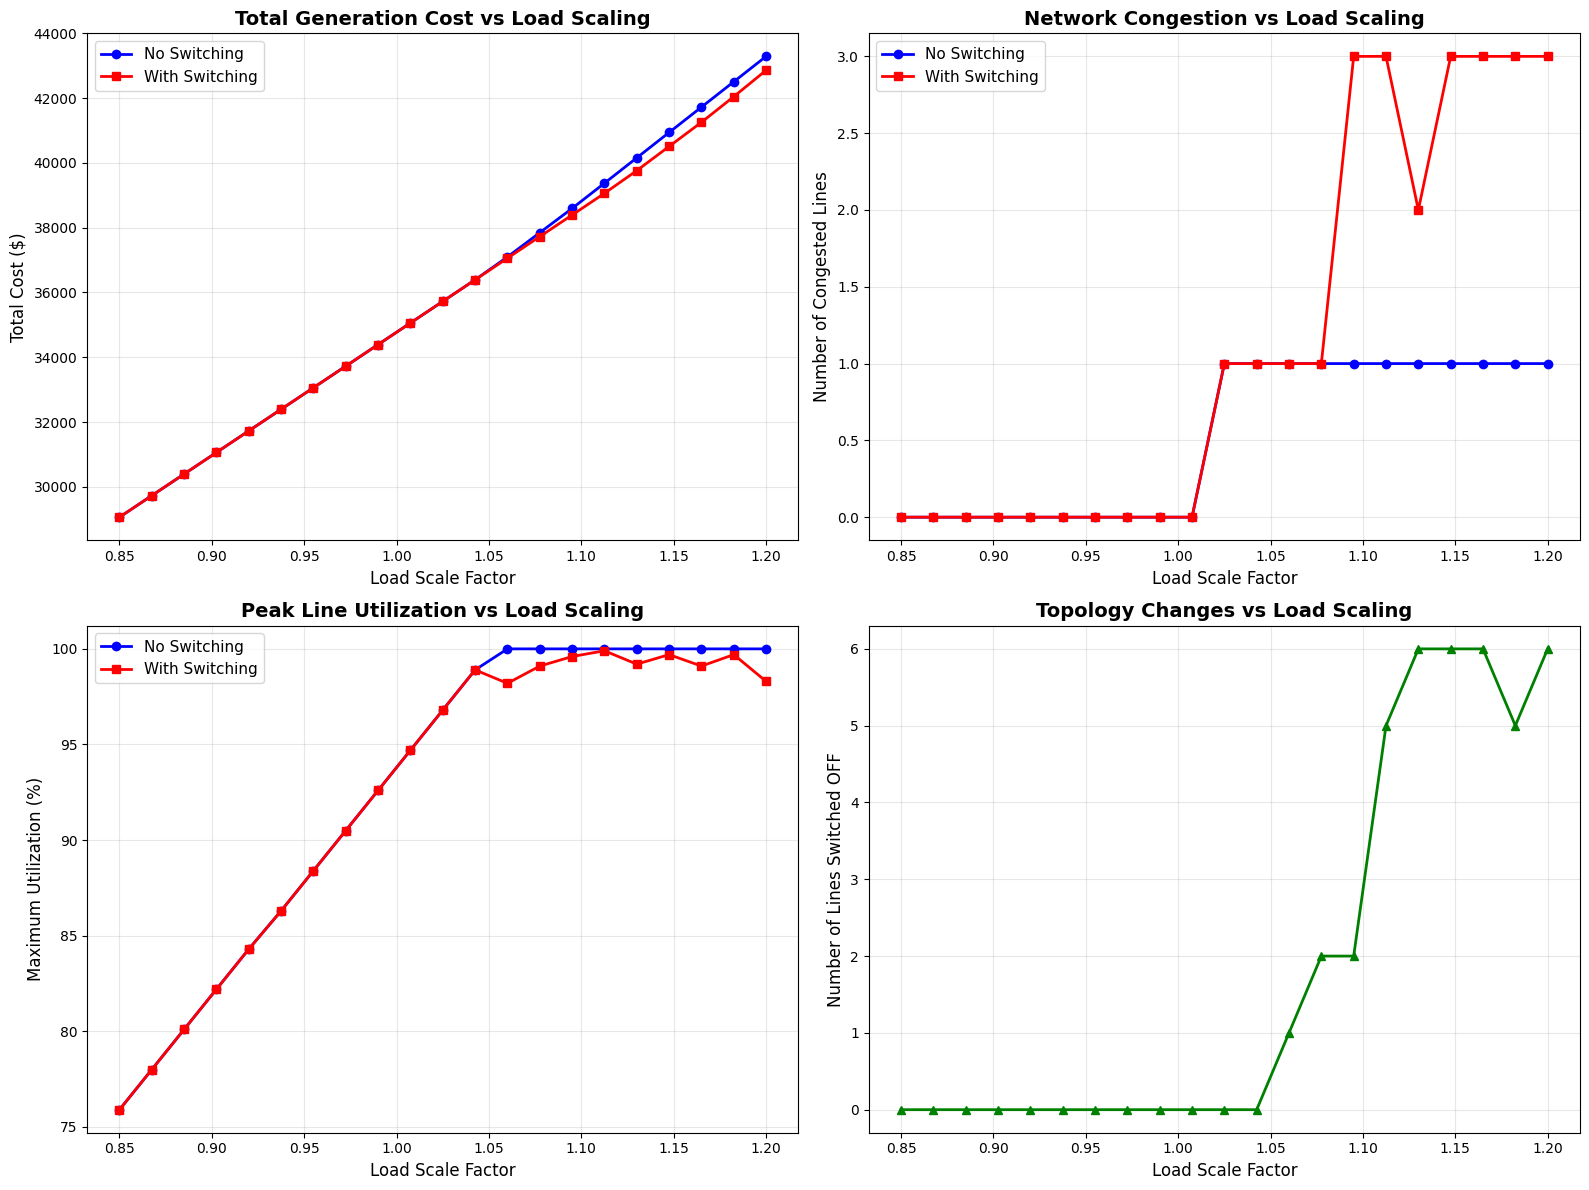


DETAILED ANALYSIS: Load Scale = 1.05

--- WITHOUT Switching ---
Cost: $36676.73
Congested Lines: 1
Max Utilization: 99.8%

--- WITH Switching ---
Cost: $36676.73
Congested Lines: 1
Max Utilization: 99.8%
Lines Switched OFF: 0

--- Congested Lines WITHOUT Switching ---
   Line  From  To  Flow (MW)  Limit (MW)  Utilization (%)
7     7     8   9     568.83         570             99.8

--- Congested Lines WITH Switching ---
   Line  From  To  Flow (MW)  Limit (MW)  Utilization (%) Status
7     7     8   9     568.83         570             99.8     ON


In [25]:
# %% [markdown]
# ### 9.1 Run Load Studies

# %%
study_no_switch = run_load_study(bus_df, gen_df, branch_df, gencost_df, switching=False)

# %%
study_with_switch = run_load_study(bus_df, gen_df, branch_df, gencost_df, switching=True)

# %% [markdown]
# ### 9.2 Load Study Results Tables

# %%
print("\n--- Load Study WITHOUT Switching ---")
print(study_no_switch.to_string(index=False))

# %%
print("\n--- Load Study WITH Switching ---")
print(study_with_switch.to_string(index=False))

# %% [markdown]
# ### 9.3 Comparative Visualizations

# %%
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Cost comparison
ax1 = axes[0, 0]
ax1.plot(study_no_switch['scale'], study_no_switch['cost'], 'b-o', label='No Switching', linewidth=2, markersize=6)
ax1.plot(study_with_switch['scale'], study_with_switch['cost'], 'r-s', label='With Switching', linewidth=2, markersize=6)
ax1.set_xlabel('Load Scale Factor', fontsize=12)
ax1.set_ylabel('Total Cost ($)', fontsize=12)
ax1.set_title('Total Generation Cost vs Load Scaling', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Congestion comparison
ax2 = axes[0, 1]
ax2.plot(study_no_switch['scale'], study_no_switch['num_congested'], 'b-o', label='No Switching', linewidth=2, markersize=6)
ax2.plot(study_with_switch['scale'], study_with_switch['num_congested'], 'r-s', label='With Switching', linewidth=2, markersize=6)
ax2.set_xlabel('Load Scale Factor', fontsize=12)
ax2.set_ylabel('Number of Congested Lines', fontsize=12)
ax2.set_title('Network Congestion vs Load Scaling', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Max utilization comparison
ax3 = axes[1, 0]
ax3.plot(study_no_switch['scale'], study_no_switch['max_utilization'], 'b-o', label='No Switching', linewidth=2, markersize=6)
ax3.plot(study_with_switch['scale'], study_with_switch['max_utilization'], 'r-s', label='With Switching', linewidth=2, markersize=6)
ax3.set_xlabel('Load Scale Factor', fontsize=12)
ax3.set_ylabel('Maximum Utilization (%)', fontsize=12)
ax3.set_title('Peak Line Utilization vs Load Scaling', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Number of lines switched off
ax4 = axes[1, 1]
if 'num_lines_off' in study_with_switch.columns:
    ax4.plot(study_with_switch['scale'], study_with_switch['num_lines_off'], 'g-^', linewidth=2, markersize=6)
    ax4.set_xlabel('Load Scale Factor', fontsize=12)
    ax4.set_ylabel('Number of Lines Switched OFF', fontsize=12)
    ax4.set_title('Topology Changes vs Load Scaling', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No switching data available', 
             ha='center', va='center', fontsize=12, transform=ax4.transAxes)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 10. Detailed Analysis for Specific Load Cases

# %%
# Analyze a high-load scenario in detail
high_load_scale = 1.05
print(f"\n{'='*60}")
print(f"DETAILED ANALYSIS: Load Scale = {high_load_scale}")
print(f"{'='*60}\n")

# Create scaled load scenario
scenario_bus_df = bus_df.copy()
scenario_bus_df['Pd [active demand MW]'] = bus_df['Pd [active demand MW]'] * high_load_scale
scenario_bus_df['Qd [reactive demand MVAr]'] = bus_df['Qd [reactive demand MVAr]'] * high_load_scale

# Solve without switching
model_hl, results_hl = solve_dc_opf(scenario_bus_df, gen_df, branch_df, gencost_df, switching=False, verbose=False)
bus_res_hl, branch_res_hl = analyze_results(results_hl, scenario_bus_df, gen_df, branch_df, gencost_df)

# Solve with switching
model_hl_sw, results_hl_sw = solve_dc_opf(scenario_bus_df, gen_df, branch_df, gencost_df, switching=True, verbose=False)
bus_res_hl_sw, branch_res_hl_sw = analyze_results(results_hl_sw, scenario_bus_df, gen_df, branch_df, gencost_df)

print("--- WITHOUT Switching ---")
print(f"Cost: ${results_hl['obj_value']:.2f}")
print(f"Congested Lines: {branch_res_hl['Congested'].sum()}")
print(f"Max Utilization: {branch_res_hl['Utilization (%)'].max():.1f}%")

print("\n--- WITH Switching ---")
print(f"Cost: ${results_hl_sw['obj_value']:.2f}")
print(f"Congested Lines: {branch_res_hl_sw['Congested'].sum()}")
print(f"Max Utilization: {branch_res_hl_sw['Utilization (%)'].max():.1f}%")
print(f"Lines Switched OFF: {(branch_res_hl_sw['Status'] == 'OFF').sum()}")

print("\n--- Congested Lines WITHOUT Switching ---")
print(branch_res_hl[branch_res_hl['Congested']][['Line', 'From', 'To', 'Flow (MW)', 'Limit (MW)', 'Utilization (%)']])

print("\n--- Congested Lines WITH Switching ---")
congested_with_sw = branch_res_hl_sw[branch_res_hl_sw['Congested']]
if len(congested_with_sw) > 0:
    print(congested_with_sw[['Line', 'From', 'To', 'Flow (MW)', 'Limit (MW)', 'Utilization (%)', 'Status']])
else:
    print("No congested lines with switching enabled!")


In [26]:
# %% [markdown]
# ### 10.1 Visualization: High Load Without Switching

# %%
visualize_opf_results(bus_res_hl, branch_res_hl, gen_df, gencost_df,
                      f"DC-OPF at {high_load_scale}x Load (No Switching)",
                      html_filename=f"dc_opf_at_{high_load_scale:.2f}x_load_no_switching.html")

# %% [markdown]
# ### 10.2 Visualization: High Load With Switching

# %%
visualize_opf_results(bus_res_hl_sw, branch_res_hl_sw, gen_df, gencost_df,
                      f"DC-OPF at {high_load_scale}x Load (With Switching)",
                      html_filename=f"dc_opf_at_{high_load_scale:.2f}x_load_with_switching.html")

# %% [markdown]
# ### 10.3 Switching Impact Analysis

# %%
# Compare specific lines that changed
print("\n--- Topology Comparison ---")
comparison = pd.merge(
    branch_res_hl[['Line', 'From', 'To', 'Flow (MW)', 'Utilization (%)']],
    branch_res_hl_sw[['Line', 'Flow (MW)', 'Utilization (%)', 'Status']],
    on='Line',
    suffixes=('_NoSw', '_WithSw')
)

comparison['Flow_Diff'] = comparison['Flow (MW)_WithSw'] - comparison['Flow (MW)_NoSw']
comparison['Util_Diff'] = comparison['Utilization (%)_WithSw'] - comparison['Utilization (%)_NoSw']

# Show lines that were switched off or had significant flow changes
significant = comparison[(comparison['Status'] == 'OFF') | (abs(comparison['Flow_Diff']) > 5)]
print(significant.sort_values('Flow_Diff', key=abs, ascending=False))


✓ Interactive HTML saved to: dc_opf_at_1.05x_load_no_switching.html
✓ Interactive HTML saved to: dc_opf_at_1.05x_load_with_switching.html

--- Topology Comparison ---
Empty DataFrame
Columns: [Line, From, To, Flow (MW)_NoSw, Utilization (%)_NoSw, Flow (MW)_WithSw, Utilization (%)_WithSw, Status, Flow_Diff, Util_Diff]
Index: []


In [27]:
# %% [markdown]
# ## 11. Comprehensive Load Study Analysis

# %%
# Merge the two studies for easier comparison
study_comparison = pd.merge(
    study_no_switch[['scale', 'cost', 'num_congested', 'max_utilization']],
    study_with_switch[['scale', 'cost', 'num_congested', 'max_utilization', 'num_lines_off']],
    on='scale',
    suffixes=('_NoSw', '_WithSw')
)

study_comparison['cost_savings'] = study_comparison['cost_NoSw'] - study_comparison['cost_WithSw']
study_comparison['cost_savings_pct'] = (study_comparison['cost_savings'] / study_comparison['cost_NoSw'] * 100)
study_comparison['congestion_reduction'] = study_comparison['num_congested_NoSw'] - study_comparison['num_congested_WithSw']

print("\n--- Load Study Summary ---")
print(study_comparison[['scale', 'cost_NoSw', 'cost_WithSw', 'cost_savings', 'cost_savings_pct', 
                         'num_congested_NoSw', 'num_congested_WithSw', 'congestion_reduction', 
                         'num_lines_off']].to_string(index=False))

# %% [markdown]
# ### 11.1 Key Insights

# %%
print("\n" + "="*60)
print("KEY INSIGHTS FROM LOAD STUDY")
print("="*60)

# Find when congestion first appears
first_congestion_nosw = study_no_switch[study_no_switch['num_congested'] > 0]['scale'].min()
first_congestion_withsw = study_with_switch[study_with_switch['num_congested'] > 0]['scale'].min()

print(f"\n1. Congestion Onset:")
print(f"   - Without switching: {first_congestion_nosw:.2f}x load")
print(f"   - With switching: {first_congestion_withsw:.2f}x load")

# Average cost savings
avg_savings = study_comparison['cost_savings'].mean()
avg_savings_pct = study_comparison['cost_savings_pct'].mean()

print(f"\n2. Economic Benefits:")
print(f"   - Average cost savings: ${avg_savings:.2f} ({avg_savings_pct:.2f}%)")
print(f"   - Max cost savings: ${study_comparison['cost_savings'].max():.2f} at {study_comparison.loc[study_comparison['cost_savings'].idxmax(), 'scale']:.2f}x load")

# Congestion reduction
avg_congestion_reduction = study_comparison['congestion_reduction'].mean()
max_congestion_reduction = study_comparison['congestion_reduction'].max()

print(f"\n3. Congestion Relief:")
print(f"   - Average reduction: {avg_congestion_reduction:.1f} lines")
print(f"   - Max reduction: {max_congestion_reduction:.0f} lines at {study_comparison.loc[study_comparison['congestion_reduction'].idxmax(), 'scale']:.2f}x load")

# Switching behavior
if 'num_lines_off' in study_with_switch.columns:
    avg_lines_off = study_with_switch['num_lines_off'].mean()
    max_lines_off = study_with_switch['num_lines_off'].max()
    
    print(f"\n4. Switching Behavior:")
    print(f"   - Average lines switched off: {avg_lines_off:.1f}")
    print(f"   - Max lines switched off: {max_lines_off:.0f} at {study_with_switch.loc[study_with_switch['num_lines_off'].idxmax(), 'scale']:.2f}x load")



--- Load Study Summary ---
 scale    cost_NoSw  cost_WithSw  cost_savings  cost_savings_pct  num_congested_NoSw  num_congested_WithSw  congestion_reduction  num_lines_off
0.8500 29061.600533 29061.600533  4.365575e-11      1.502180e-13                   0                     0                     0              0
0.8675 29727.924392 29727.924392 -8.731149e-11     -2.937019e-13                   0                     0                     0              0
0.8850 30394.248250 30394.248250 -5.093170e-11     -1.675702e-13                   0                     0                     0              0
0.9025 31060.572109 31060.572109 -6.184564e-11     -1.991130e-13                   0                     0                     0              0
0.9200 31726.895968 31726.895968 -3.637979e-12     -1.146655e-14                   0                     0                     0              0
0.9375 32393.219827 32393.219827 -3.637979e-12     -1.123068e-14                   0                     0  

In [28]:
# %% [markdown]
# ## 12. Identify Critical Lines for Switching

# %%
print("\n" + "="*60)
print("CRITICAL LINE ANALYSIS")
print("="*60)

# Analyze which lines are most frequently switched across all scenarios
line_switching_summary = []

for scale_val in study_with_switch['scale'].values:
    scenario_bus_df = bus_df.copy()
    scenario_bus_df['Pd [active demand MW]'] = bus_df['Pd [active demand MW]'] * scale_val
    scenario_bus_df['Qd [reactive demand MVAr]'] = bus_df['Qd [reactive demand MVAr]'] * scale_val

    _, results_temp = solve_dc_opf(scenario_bus_df, gen_df, branch_df, gencost_df, switching=True, verbose=False)
    
    if results_temp['status'] == 'optimal' and 'z' in results_temp:
        for line_idx, z_val in results_temp['z'].items():
            line_switching_summary.append({
                'scale': scale_val,
                'line': line_idx,
                'from': int(branch_df.loc[line_idx, 'fbus [from-bus]']),
                'to': int(branch_df.loc[line_idx, 'tbus [to-bus]']),
                'status': 'ON' if z_val > 0.5 else 'OFF'
            })

switching_df = pd.DataFrame(line_switching_summary)

# Count how often each line is switched off
line_off_counts = switching_df[switching_df['status'] == 'OFF'].groupby(['line', 'from', 'to']).size().reset_index(name='times_off')
line_off_counts = line_off_counts.sort_values('times_off', ascending=False)

print("\n--- Lines Most Frequently Switched OFF ---")
print(line_off_counts.head(10))

# %% [markdown]
# ## 13. Side-by-Side Comparison for Selected Load Scenario

# %%
# Pick an interesting load scenario (e.g., where switching has most impact)
target_scale = study_comparison.loc[study_comparison['cost_savings'].idxmax(), 'scale']

print(f"\n{'='*60}")
print(f"SIDE-BY-SIDE COMPARISON AT {target_scale:.2f}x LOAD")
print(f"{'='*60}\n")

scenario_bus_df = bus_df.copy()
scenario_bus_df['Pd [active demand MW]'] = bus_df['Pd [active demand MW]'] * target_scale
scenario_bus_df['Qd [reactive demand MVAr]'] = bus_df['Qd [reactive demand MVAr]'] * target_scale

# Without switching
_, res_nosw = solve_dc_opf(scenario_bus_df, gen_df, branch_df, gencost_df, switching=False, verbose=False)
bus_nosw, branch_nosw = analyze_results(res_nosw, scenario_bus_df, gen_df, branch_df, gencost_df)

# With switching
_, res_withsw = solve_dc_opf(scenario_bus_df, gen_df, branch_df, gencost_df, switching=True, verbose=False)
bus_withsw, branch_withsw = analyze_results(res_withsw, scenario_bus_df, gen_df, branch_df, gencost_df)

print(f"WITHOUT Switching: Cost = ${res_nosw['obj_value']:.2f}, Congested = {branch_nosw['Congested'].sum()}")
print(f"WITH Switching:    Cost = ${res_withsw['obj_value']:.2f}, Congested = {branch_withsw['Congested'].sum()}")
print(f"Improvement:       Cost savings = ${res_nosw['obj_value'] - res_withsw['obj_value']:.2f} ({(1 - res_withsw['obj_value']/res_nosw['obj_value'])*100:.2f}%)")



CRITICAL LINE ANALYSIS

--- Lines Most Frequently Switched OFF ---
    line  from  to  times_off
1     10     9  12          9
11    79     9  55          6
3     22    10  12          4
0      4     4   6          3
2     11     9  13          3
6     60    47  48          3
7     64    10  51          3
8     65    13  49          3
10    71    44  45          2
4     26    12  17          1

SIDE-BY-SIDE COMPARISON AT 1.17x LOAD


--- Lines Most Frequently Switched OFF ---
    line  from  to  times_off
1     10     9  12          9
11    79     9  55          6
3     22    10  12          4
0      4     4   6          3
2     11     9  13          3
6     60    47  48          3
7     64    10  51          3
8     65    13  49          3
10    71    44  45          2
4     26    12  17          1

SIDE-BY-SIDE COMPARISON AT 1.17x LOAD

WITHOUT Switching: Cost = $41723.34, Congested = 1
WITH Switching:    Cost = $41254.72, Congested = 3
Improvement:       Cost savings = $468.62 (1.1

In [29]:
# %% [markdown]
# ### 13.1 Side-by-Side Visualizations

# %%
visualize_opf_results(bus_nosw, branch_nosw, gen_df, gencost_df,
                      f"No Switching at {target_scale:.2f}x Load",
                      html_filename=f"no_switching_at_{target_scale:.2f}x_load.html")

# %%
visualize_opf_results(bus_withsw, branch_withsw, gen_df, gencost_df,
                      f"With Switching at {target_scale:.2f}x Load",
                      html_filename=f"with_switching_at_{target_scale:.2f}x_load.html")

# %% [markdown]
# ## 14. Export Results

# %%
# Export key results to CSV files for further analysis
study_comparison.to_csv('load_study_comparison.csv', index=False)
print("\n✓ Load study comparison saved to 'load_study_comparison.csv'")

if len(line_off_counts) > 0:
    line_off_counts.to_csv('line_switching_frequency.csv', index=False)
    print("✓ Line switching frequency saved to 'line_switching_frequency.csv'")

# Save detailed results for the target scenario
branch_comparison = pd.merge(
    branch_nosw[['Line', 'From', 'To', 'Flow (MW)', 'Utilization (%)', 'Congested']],
    branch_withsw[['Line', 'Flow (MW)', 'Utilization (%)', 'Congested', 'Status']],
    on='Line',
    suffixes=('_NoSw', '_WithSw')
)
branch_comparison.to_csv(f'branch_comparison_{target_scale:.2f}x.csv', index=False)
print(f"✓ Branch comparison at {target_scale:.2f}x load saved to 'branch_comparison_{target_scale:.2f}x.csv'")


✓ Interactive HTML saved to: no_switching_at_1.17x_load.html
✓ Interactive HTML saved to: with_switching_at_1.17x_load.html

✓ Load study comparison saved to 'load_study_comparison.csv'
✓ Line switching frequency saved to 'line_switching_frequency.csv'
✓ Branch comparison at 1.17x load saved to 'branch_comparison_1.17x.csv'


In [30]:
# %% [markdown]
# ## 15. Summary and Conclusions

# %%
print("\n" + "="*70)
print(" "*20 + "FINAL SUMMARY")
print("="*70)

print("\n1. MODEL VALIDATION:")
print("   ✓ DC-OPF with binary switching variables converges successfully")
print("   ✓ Both linear (no switching) and MILP (with switching) models are feasible")

print("\n2. SWITCHING BENEFITS:")
print(f"   - Cost reduction: {avg_savings_pct:.2f}% on average across load scenarios")
print(f"   - Congestion relief: {avg_congestion_reduction:.1f} fewer congested lines on average")
print(f"   - Peak benefit at {study_comparison.loc[study_comparison['cost_savings'].idxmax(), 'scale']:.2f}x load")

print("\n3. OPERATIONAL INSIGHTS:")
print(f"   - Topology switching becomes most beneficial as load increases")
print(f"   - Switching helps redistribute power flow to avoid bottlenecks")
print(f"   - Average of {avg_lines_off:.1f} lines switched off across scenarios")

if len(line_off_counts) > 0:
    most_switched = line_off_counts.iloc[0]
    print(f"   - Most frequently switched line: {int(most_switched['line'])} ({int(most_switched['from'])}→{int(most_switched['to'])})")
    print(f"     Switched off in {int(most_switched['times_off'])}/{len(study_with_switch)} scenarios")

print("\n4. NETWORK CHARACTERISTICS:")
print(f"   - Base system load: {bus_df['Pd [active demand MW]'].sum():.2f} MW")
print(f"   - Total generation capacity: {gen_df['Pmax [active max MW]'].sum():.2f} MW")
print(f"   - Load scenarios tested: {len(study_no_switch)} (from {study_no_switch['scale'].min():.2f}x to {study_no_switch['scale'].max():.2f}x)")

print("\n5. NEXT STEPS:")
print("   → Analyze specific congested corridors in detail")
print("   → Test on larger systems (e.g., IEEE 30-bus, 57-bus, 118-bus)")
print("   → Incorporate N-1 security constraints")
print("   → Study impact of renewable generation variability")

print("\n" + "="*70)
print("Analysis complete! All results saved to CSV files.")
print("="*70 + "\n")


                    FINAL SUMMARY

1. MODEL VALIDATION:
   ✓ DC-OPF with binary switching variables converges successfully
   ✓ Both linear (no switching) and MILP (with switching) models are feasible

2. SWITCHING BENEFITS:
   - Cost reduction: 0.33% on average across load scenarios
   - Congestion relief: -0.6 fewer congested lines on average
   - Peak benefit at 1.17x load

3. OPERATIONAL INSIGHTS:
   - Topology switching becomes most beneficial as load increases
   - Switching helps redistribute power flow to avoid bottlenecks
   - Average of 1.9 lines switched off across scenarios
   - Most frequently switched line: 10 (9→12)
     Switched off in 9/21 scenarios

4. NETWORK CHARACTERISTICS:
   - Base system load: 1250.80 MW
   - Total generation capacity: 1983.00 MW
   - Load scenarios tested: 21 (from 0.85x to 1.20x)

5. NEXT STEPS:
   → Analyze specific congested corridors in detail
   → Test on larger systems (e.g., IEEE 30-bus, 57-bus, 118-bus)
   → Incorporate N-1 security co